<a href="https://colab.research.google.com/github/Kavishka2401/CustomerChurnPredictionSystem/blob/master/2_Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Data Pre-Processing for Neural Networks**

In [ ]:
# Mount the google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Provide path
data=pd.read_csv('/content/drive/MyDrive/Customer_Churn_Data.csv')

# Make a copy of the original dataset to work with
data_copy = data.copy()
df_nn = data_copy

In [ ]:
import pandas as pd

# Show all columns
pd.set_option('display.max_columns', None)

# Show all rows if needed
pd.set_option('display.max_rows', None)

# Prevent truncation of long strings in cells
pd.set_option('display.max_colwidth', None)
df_nn.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
# Create a numeric column for TotalCharges and drop object column
df_nn['TotalCharges_numeric'] = pd.to_numeric(df_nn['TotalCharges'], errors='coerce')
df_nn = df_nn.drop('TotalCharges', axis=1)

# Check for missing values after conversion
missing_total_charges = df_nn['TotalCharges_numeric'].isnull().sum()
print(f"Missing values in TotalCharges_numeric: {missing_total_charges}")

Missing values in TotalCharges_numeric: 11


In [ ]:
# Display rows with missing TotalCharges_numeric
missing_rows = df_nn[df_nn['TotalCharges_numeric'].isnull()]
missing_rows

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Churn,TotalCharges_numeric
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,No,NaN
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,No,NaN
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,No,NaN
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,No,NaN
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,No,NaN
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,No,NaN
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,No,NaN
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,No,NaN
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,No,NaN
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,No,NaN


In [ ]:
# Compute median of TotalCharges_numeric
median_total_charges = df_nn['TotalCharges_numeric'].median()

# Impute missing values with median
df_nn['TotalCharges_numeric'] = df_nn['TotalCharges_numeric'].fillna(median_total_charges)

In [ ]:
# Check if imputation has worked
check_missing_rows = df_nn[df_nn['TotalCharges_numeric'].isnull()]
check_missing_rows

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Churn,TotalCharges_numeric


In [ ]:
# Drop customerID
df_nn = df_nn.drop('customerID', axis=1)

In [ ]:
# Feature Engineering
df_nn['AvgChargePerMonth'] = df_nn['TotalCharges_numeric'] / (df_nn['tenure'] + 1)

In [ ]:
from sklearn.feature_selection import SelectKBest, chi2
import pandas as pd

# Separate features and target
X = df_nn.drop('Churn', axis=1)
y = df_nn['Churn']

# Check numeric columns
numeric_cols = X.select_dtypes(include=np.number).columns

# Check for negative values
for col in numeric_cols:
    if (X[col] < 0).any():
        print(f"Column '{col}' has negative values")

# Check for NaNs or infinite values
print(X[numeric_cols].isnull().sum())
print(np.isinf(X[numeric_cols]).sum())

SeniorCitizen           0
tenure                  0
MonthlyCharges          0
TotalCharges_numeric    0
AvgChargePerMonth       0
dtype: int64
SeniorCitizen           0
tenure                  0
MonthlyCharges          0
TotalCharges_numeric    0
AvgChargePerMonth       0
dtype: int64


In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import SelectKBest, chi2
import pandas as pd

# Identify categorical columns (excluding target)
categorical_columns = df_nn.select_dtypes(include='object').columns.drop('Churn').tolist()
print("Categorical columns (excluding 'Churn'):", categorical_columns)

# Temporary Label Encoding for Chi-Square
df_label = df_nn.copy()
for col in categorical_columns:
    df_label[col] = LabelEncoder().fit_transform(df_label[col])

# Encode target for Chi-Square
y = df_label['Churn'].map({'No': 0, 'Yes': 1})
X = df_label.drop('Churn', axis=1)

# Apply Chi-Square to select top k features
k = 12
selector = SelectKBest(score_func=chi2, k=k)
selector.fit(X, y)

chi_scores = pd.Series(selector.scores_, index=X.columns).sort_values(ascending=False)
top_features = chi_scores.head(k)
print("Top 12 Features with Chi-Squared Scores:")
print(top_features)



Categorical columns (excluding 'Churn'): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Top 12 Features with Chi-Squared Scores:
TotalCharges_numeric    627340.305176
tenure                   16278.923685
MonthlyCharges            3680.787699
Contract                  1115.780167
OnlineSecurity             551.611529
TechSupport                523.303866
OnlineBackup               230.086520
DeviceProtection           191.303140
SeniorCitizen              134.351545
Dependents                 133.036443
PaperlessBilling           105.680863
AvgChargePerMonth           94.812816
dtype: float64


/tmp/ipython-input-2380471740.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Chi2_Score', y='Feature', data=chi2_df, palette='viridis')


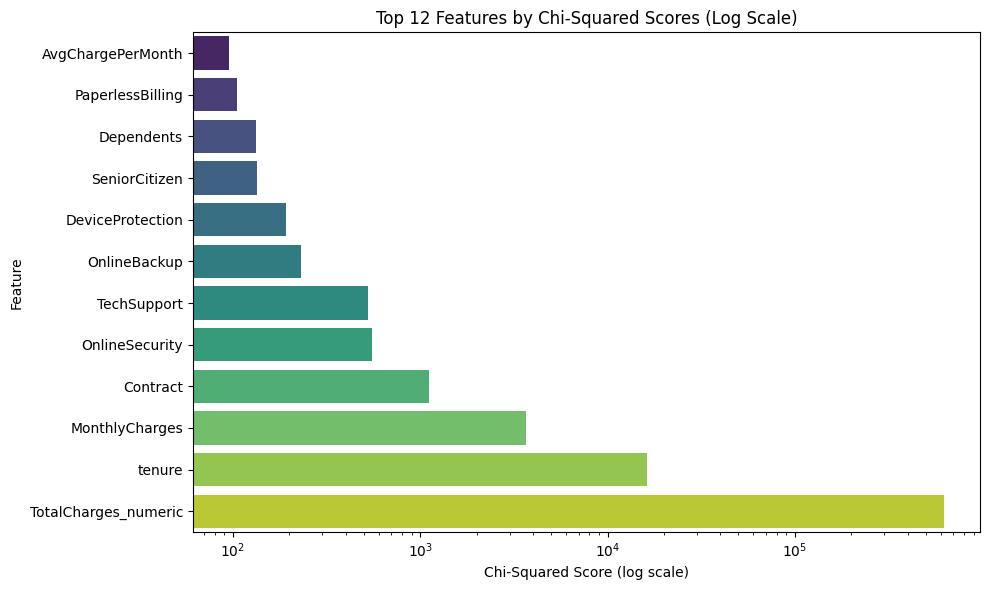

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Chi-squared scores
chi2_scores = {
    'TotalCharges_numeric': 627340.305176,
    'tenure': 16278.923685,
    'MonthlyCharges': 3680.787699,
    'Contract': 1115.780167,
    'OnlineSecurity': 551.611529,
    'TechSupport': 523.303866,
    'OnlineBackup': 230.086520,
    'DeviceProtection': 191.303140,
    'SeniorCitizen': 134.351545,
    'Dependents': 133.036443,
    'PaperlessBilling': 105.680863,
    'AvgChargePerMonth': 94.812816
}

# Convert to DataFrame
chi2_df = pd.DataFrame(list(chi2_scores.items()), columns=['Feature', 'Chi2_Score'])
chi2_df = chi2_df.sort_values(by='Chi2_Score', ascending=True)

# Plot with log scale
plt.figure(figsize=(10,6))
sns.barplot(x='Chi2_Score', y='Feature', data=chi2_df, palette='viridis')
plt.xscale('log')  # Use logarithmic scale
plt.title('Top 12 Features by Chi-Squared Scores (Log Scale)')
plt.xlabel('Chi-Squared Score (log scale)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [ ]:
# Keep only top features in original df (not label encoded)
selected_features = top_features.index.tolist()
df_nn = df_nn[selected_features + ['Churn']]

# One-hot encoding ONLY on selected categorical columns
selected_cat_cols = [col for col in categorical_columns if col in selected_features]

df_nn = pd.get_dummies(df_nn, columns=selected_cat_cols, drop_first=True)

# Convert boolean columns to int
bool_cols = df_nn.select_dtypes(include='bool').columns
df_nn[bool_cols] = df_nn[bool_cols].astype(int)

# Encode target variable Churn
df_nn['Churn'] = df_nn['Churn'].map({'No': 0, 'Yes': 1})

# Check final dataset
print("Shape after encoding:", df_nn.shape)
print("Columns after encoding:", df_nn.columns.tolist())

Shape after encoding: (7043, 18)
Columns after encoding: ['TotalCharges_numeric', 'tenure', 'MonthlyCharges', 'SeniorCitizen', 'AvgChargePerMonth', 'Churn', 'Dependents_Yes', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes']


In [ ]:
# IQR method to detect outliers
num_features = ['TotalCharges_numeric', 'MonthlyCharges', 'tenure','AvgChargePerMonth']

for col in num_features:
    Q1 = df_nn[col].quantile(0.25)
    Q3 = df_nn[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df_nn[(df_nn[col] < lower_bound) | (df_nn[col] > upper_bound)]
    print(f"{col}: {len(outliers)} outliers")

TotalCharges_numeric: 0 outliers
MonthlyCharges: 0 outliers
tenure: 0 outliers
AvgChargePerMonth: 11 outliers


In [ ]:
# Checking if skew handling should be done to the numerical columns
df_nn[['TotalCharges_numeric', 'MonthlyCharges', 'tenure','AvgChargePerMonth']].skew()

,0
TotalCharges_numeric,0.963789
MonthlyCharges,-0.220524
tenure,0.239540
AvgChargePerMonth,16.383722


In [ ]:
# Log transform (Skew handling)
df_nn['TotalCharges_numeric'] = np.log1p(df_nn['TotalCharges_numeric'])
df_nn['AvgChargePerMonth'] = np.log1p(df_nn['AvgChargePerMonth'])

In [ ]:
# Checking if skew handling should be done to the numerical columns
df_nn[['TotalCharges_numeric', 'MonthlyCharges', 'tenure','AvgChargePerMonth']].skew()

,0
TotalCharges_numeric,-0.744502
MonthlyCharges,-0.220524
tenure,0.239540
AvgChargePerMonth,-0.439749


In [ ]:
from sklearn.preprocessing import MinMaxScaler

# List of numerical features to scale
num_features = ['TotalCharges_numeric', 'MonthlyCharges', 'tenure','AvgChargePerMonth']

# Initialize MinMaxScaler
scaler = MinMaxScaler()

# Fit the scaler on the numerical features and transform
df_nn[num_features] = scaler.fit_transform(df_nn[num_features])

# Check the result
print(df_nn[num_features].describe())

       TotalCharges_numeric  MonthlyCharges       tenure  AvgChargePerMonth
count           7043.000000     7043.000000  7043.000000        7043.000000
mean               0.650613        0.462803     0.449599           0.326579
std                0.254000        0.299403     0.341104           0.132372
min                0.000000        0.000000     0.000000           0.000000
25%                0.495386        0.171642     0.125000           0.200146
50%                0.699806        0.518408     0.402778           0.367464
75%                0.863578        0.712438     0.763889           0.433306
max                1.000000        1.000000     1.000000           1.000000


In [ ]:
df_nn.to_csv("/content/drive/MyDrive/processed_data_NN.csv", index=False)
print("Saved successfully!")